## An alternative approach to WD classification training

In the following notebook we will take a look at an alternative approach for the problem at hand. Here, we will train a neural network on all the available data ant it's original labels, so as to try to replicate the multiple criteria used by the many evaluators. We will try to compare this interesting approach along with our current one over the validation sets.

We will also define a new precision metric for our training, which will be the dot product of two vectors: The vector consisting of the one-hot encoded labels, added up per target id, and the vector consisting of the predictions of our neural network, added up in the same fasion. So, the square root of this quantity will be an approximation of the euclidean norm of the labels vector. 



In [2]:
import pandas as pd
import os
from pathlib import Path
import numpy as np

We will create a folder with the same name of our jupyter notebook so as to store any generated files.

In [3]:
current_dir =  Path(globals()['_dh'][0])
try:
    os.mkdir(os.path.join(current_dir, '1.0-jrb-alternative-approach'))
except:
    print("Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.")

# Load clean labels from interim datafolder, generated by the make_datasets.py

project_dir =  Path(globals()['_dh'][0]).parent
    

In [3]:
# Loading training, test and validation sets.

cl_csv_path = os.path.join(project_dir, r'data/interim/clean_labels.csv')
cl_df = pd.read_csv (cl_csv_path)

In [4]:
cl_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,OK,spec-15249-59265-04601916346-21899.png,59265,4601916346
1,sdX,23360,BLEND,spec-15301-59338-04602344336-23360.png,59338,4602344336
2,WDA,18900,SNR,spec-15113-59217-04538755416-18900.png,59217,4538755416
3,WDA,18575,OK,spec-15086-59267-04474143209-18575.png,59267,4474143209
4,WD,20528,SNR,spec-15198-59269-04351438385-20528.png,59269,4351438385
...,...,...,...,...,...,...
35248,WDA,15895,SNR,spec-15011-59222-04399876473-15895.png,59222,4399876473
35249,WDA,20605,OK,spec-15200-59324-04589320996-20605.png,59324,4589320996
35250,WDA,19388,OK,spec-15193-59243-04594923329-19388.png,59243,4594923329
35251,DUNNO,19161,SNR,spec-15121-59212-04342114705-19161.png,59212,4342114705


We'll modify our pre-processing function from the make_dataset.py file.

In [5]:
def label_preprocess_v1(labels_df: pd.DataFrame) -> pd.DataFrame:
    # Removing observations with data quality issues:

    labels_df.drop(labels_df[labels_df['Data Quality'] != 'OK'].index, inplace = True)

    # parsed_df = parsed_df.astype({"DB ID": 'int64', "MJD": 'int64', "Target ID" : 'int64'})

    # Remove non interesting classes, note that this is done after a label consensus is reached.

    labels_df.drop(labels_df.index[labels_df['Classification'] == 'DUNNO'], inplace = True)
    labels_df.drop(labels_df.index[labels_df['Classification'] == 'UNCLASS'], inplace = True)
    labels_df.drop(labels_df.index[labels_df['Classification'] == 'STAR'], inplace = True)
    labels_df.drop(labels_df.index[labels_df['Classification'] == 'EXGAL'], inplace = True)

    return labels_df

In [6]:
parsed_df = label_preprocess_v1(cl_df)
parsed_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,OK,spec-15249-59265-04601916346-21899.png,59265,4601916346
3,WDA,18575,OK,spec-15086-59267-04474143209-18575.png,59267,4474143209
5,WDA,22243,OK,spec-15266-59306-04592699543-22243.png,59306,4592699543
6,WDA,19555,OK,spec-15165-59202-04545012720-19555.png,59202,4545012720
7,WD,20892,OK,spec-15221-59245-04306649216-20892.png,59245,4306649216
...,...,...,...,...,...,...
35238,sdX,24966,OK,spec-15345-59327-04879862482-24966.png,59327,4879862482
35240,WDC,19293,OK,spec-15190-59248-04553795050-19293.png,59248,4553795050
35241,WDA,23579,OK,spec-15306-59289-04600807007-23579.png,59289,4600807007
35249,WDA,20605,OK,spec-15200-59324-04589320996-20605.png,59324,4589320996


Now we will match this set with our currently available .dat files.

In [7]:
import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../src'))
import src.data.make_dataset as mds

In [8]:
match_data = mds.match_dat_files(parsed_df, sdss_datfiles_path=os.path.join(project_dir,  r'data\raw\sdss_dat_files'))

In [9]:
match_data

,filename,classID
0,cb_uvex4\SDSSJ121828.50+300201.3_15249-59265-0...,WDA
1,wd\SDSSJ070928.42-115148.7_15086-59267-0068_44...,WDA
2,wd\SDSSJ092633.22+031704.7_15266-59306-0129_45...,WDA
3,wd\SDSSJ084230.03+014543.0_15165-59202-0055_45...,WDA
4,wd\SDSSJ031251.58+530140.4_15221-59245-0050_43...,WD
...,...,...
18203,cb_gaiagalex\SDSSJ175244.87-002230.4_15345-593...,sdX
18204,wd\SDSSJ073515.14+362444.7_15190-59248-0371_45...,WDC
18205,cb_uvex2\SDSSJ143740.60+040554.5_15306-59289-0...,WDA
18206,cb_uvex2\SDSSJ134454.43-064713.3_15200-59324-0...,WDA


Now we can define our training, validation test sets.

In [10]:
import src.features.build_features as bfs

In [11]:
train_set, test_set, valid_set = bfs.make_stratified_sets(match_data, train_set_size=0.6, validation_test_split=0.5)

We will proceed to create our numpy arrays for each set, using the spectrum data. (For me this took about 21 min)

In [12]:
sdss_data_path = os.path.join(project_dir, r'data\raw\sdss_dat_files')
test_spectrum_matrix = bfs.data_processing_and_loading(sdss_data_path, test_set)
train_spectrum_matrix = bfs.data_processing_and_loading(sdss_data_path, train_set)
valid_spectrum_matrix = bfs.data_processing_and_loading(sdss_data_path, valid_set)

In [13]:
# train_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\alt_train_spectrum_matrix.npy'))
# valid_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\alt_valid_spectrum_matrix.npy'))

In [14]:
prefix = 'alt'
save_folder = os.path.join(current_dir, '1.0-jrb-alternative-approach')
np.save(os.path.join(save_folder, prefix+'_train_spectrum_matrix.npy'), train_spectrum_matrix)
np.save(os.path.join(save_folder, prefix+'_test_spectrum_matrix.npy'), test_spectrum_matrix)
np.save(os.path.join(save_folder, prefix+'_valid_spectrum_matrix.npy'), valid_spectrum_matrix)

Let's also do our one hot encoding.

In [15]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse=False)
train_label_matrix = ohe.fit_transform(train_set[['classID']])
test_label_matrix = ohe.fit_transform(test_set[['classID']])
valid_label_matrix = ohe.fit_transform(valid_set[['classID']])

In [16]:
np.save(os.path.join(save_folder, prefix+'_train_label_matrix.npy'), train_label_matrix)
np.save(os.path.join(save_folder, prefix+'_test_label_matrix.npy'), test_label_matrix)
np.save(os.path.join(save_folder, prefix+'_valid_label_matrix.npy'), valid_label_matrix )

In [17]:
print(train_spectrum_matrix.shape, train_label_matrix.shape, valid_spectrum_matrix.shape,  valid_label_matrix.shape)

(10912, 4200) (10912, 12) (3639, 4200) (3639, 12)


And now we can try to train a preliminary model! Let's try our precious cnn... First, we will upsample our dataset.

In [18]:
# you can run pip install imblearn to get the imbalanced learn module.
# Resampling the majority dataset in order to balance the set.

from imblearn.over_sampling import RandomOverSampler
over_sampler = RandomOverSampler(random_state=40, sampling_strategy='not majority')
X_over, Y_over = over_sampler.fit_resample(train_spectrum_matrix, train_label_matrix)

_, counts = np.unique(Y_over, axis=0, return_counts=True)

counts

array([6709, 6709, 6709, 6709, 6709, 6709, 6709, 6709, 6709, 6709, 6709,
       6709], dtype=int64)

In [19]:
train_set.reset_index(inplace=True)
train_set

,index,filename,classID
0,10865,cb_uvex2\SDSSJ061640.79+422426.0_15197-59271-0...,WD+MS
1,17765,wd\SDSSJ134305.31+270624.0_15301-59314-0426_46...,WDC
2,11223,wd\SDSSJ134614.52+015127.1_15201-59328-0445_45...,WDA
3,15662,wd\SDSSJ162904.93+430945.3_15308-59312-0356_43...,WDC
4,5304,wd\SDSSJ153405.13+063917.7_15272-59326-0013_51...,WDB
...,...,...,...
10907,3983,wd\SDSSJ074648.91+375411.5_15017-59163-0269_45...,WDA
10908,5758,cb_uvex2\SDSSJ165712.59+352616.7_15310-59352-0...,WDC
10909,5972,cb_uvex2\SDSSJ163512.86+003437.1_15275-59337-0...,CV
10910,4706,wd\SDSSJ160534.90+531123.9_15330-59344-0453_43...,WDA


Now we will decode the one hot encoding perfomed on our dataset.

In [20]:
import src.visualization.visualize as vsz

ohe_dict = vsz.ohe_decoder(train_set['classID'], train_label_matrix)
star_class = vsz.sort_ohe(ohe_dict)
ohe_dict

{'WD+MS': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDC': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
 'WDA': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDB': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 'WDO': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
 'WDELM': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 'WDH': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 'WD': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'CV': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDZ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
 'sdX': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 'WDQ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])}

In [21]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Flatten
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from keras.layers.core import Dropout

In [22]:
# import tensorflow as tf
# from tensorflow.python.eager import context

# _ = tf.Variable([1])

# context._context = None
# context._create_context()

In [23]:
# # Limit CPU usage of tensorflow.



# num_threads = 2
# os.environ["OMP_NUM_THREADS"] = "0"
# # os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
# # os.environ["TF_NUM_INTEROP_THREADS"] = "2"

# tf.config.threading.set_inter_op_parallelism_threads(2)
# tf.config.threading.set_intra_op_parallelism_threads(112)
# tf.config.set_soft_device_placement(True)

In [24]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=15)
mc = ModelCheckpoint('overfitted_model.h5', monitor='val_loss', mode='min', verbose=1, save_best_only=True)

model = Sequential([Conv1D(filters=128, kernel_size=4, activation='relu', strides=2, input_shape=(X_over.shape[1],1)),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=64, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=32, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=16, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Flatten(),
                    Dense(128, activation='relu', kernel_initializer='uniform'),
                    Dropout(0.5),
                    Dense(64, activation='relu', kernel_initializer='uniform'),
                    Dropout(0.5),
                    Dense(32, activation='relu', kernel_initializer='uniform'),
                    Dense(len(star_class), activation='softmax', kernel_initializer='uniform')])

opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
history = model.fit(X_over, Y_over, batch_size=256, epochs=20 , validation_data=(valid_spectrum_matrix, valid_label_matrix), callbacks=[es, mc])

Epoch 1/20
315/315 [==============================] - ETA: 0s - loss: 1.9400 - accuracy: 0.3099
Epoch 1: val_loss improved from inf to 1.15087, saving model to best_model_try2.h5
315/315 [==============================] - 301s 954ms/step - loss: 1.9400 - accuracy: 0.3099 - val_loss: 1.1509 - val_accuracy: 0.7703
Epoch 2/20
315/315 [==============================] - ETA: 0s - loss: 1.3424 - accuracy: 0.5369
Epoch 2: val_loss improved from 1.15087 to 1.01725, saving model to best_model_try2.h5
315/315 [==============================] - 309s 980ms/step - loss: 1.3424 - accuracy: 0.5369 - val_loss: 1.0173 - val_accuracy: 0.7912
Epoch 3/20
315/315 [==============================] - ETA: 0s - loss: 1.1726 - accuracy: 0.5953
Epoch 3: val_loss improved from 1.01725 to 0.88533, saving model to best_model_try2.h5
315/315 [==============================] - 310s 984ms/step - loss: 1.1726 - accuracy: 0.5953 - val_loss: 0.8853 - val_accuracy: 0.7991
Epoch 4/20
315/315 [==============================

In [26]:
import matplotlib.pyplot as plt

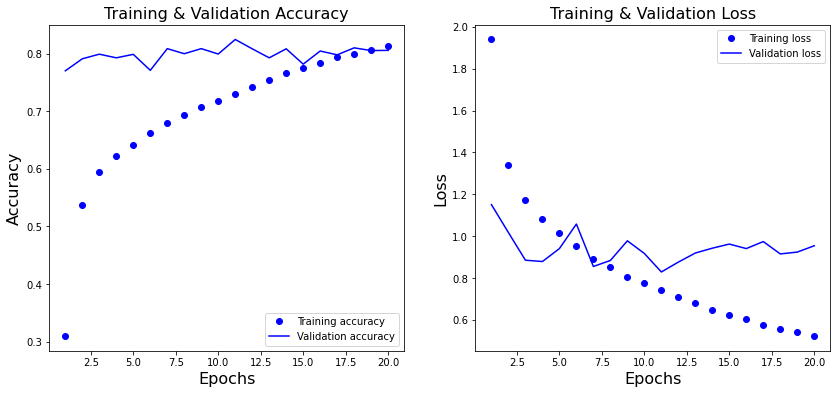

In [27]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
 
epochs = range(1, len(loss_values) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
#
# Plot the model accuracy vs Epochs
#
ax[0].plot(epochs, accuracy, 'bo', label='Training accuracy')
ax[0].plot(epochs, val_accuracy, 'b', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()
#
# Plot the loss vs Epochs
#
ax[1].plot(epochs, loss_values, 'bo', label='Training loss')
ax[1].plot(epochs, val_loss_values, 'b', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()